# Import

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay, auc, precision_recall_curve, PrecisionRecallDisplay
from scipy import stats as st
from collections import Counter
from category_encoders.count import CountEncoder
import seaborn as sns
import optuna
import warnings
warnings.filterwarnings('ignore')

# Download data from Don’tGetKicked competition.

In [6]:
train_df = pd.read_csv("data/training.csv")
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              72983 non-null  int64  
 1   IsBadBuy                           72983 non-null  int64  
 2   PurchDate                          72983 non-null  object 
 3   Auction                            72983 non-null  object 
 4   VehYear                            72983 non-null  int64  
 5   VehicleAge                         72983 non-null  int64  
 6   Make                               72983 non-null  object 
 7   Model                              72983 non-null  object 
 8   Trim                               70623 non-null  object 
 9   SubModel                           72975 non-null  object 
 10  Color                              72975 non-null  object 
 11  Transmission                       72974 non-null  obj

### Preprocessing data first

<Axes: >

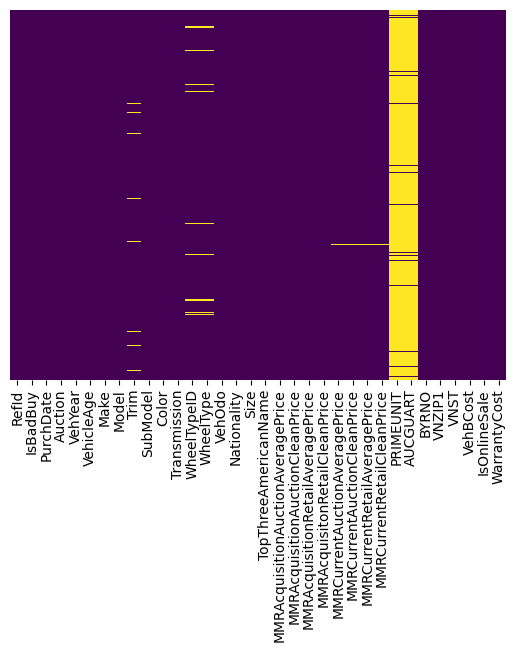

In [7]:
sns.heatmap(train_df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

### Two columns are hust NANs, they are not going to be helpful in learning rate

In [8]:
train_df.drop(labels=["PRIMEUNIT","AUCGUART"], axis=1, inplace=True) 

### Other NAN values are not so many. Let`s try to get rid of them and count how much data we will loose

In [9]:
train_df.dropna(inplace=True)

### Making sure no NAN values are left.

<Axes: >

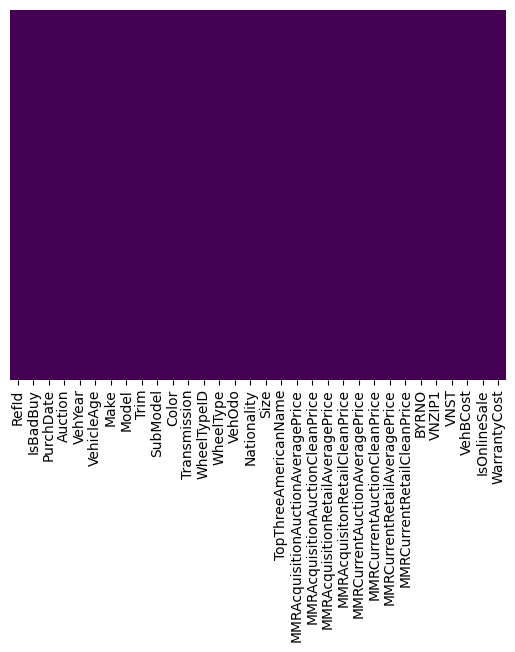

In [10]:
sns.heatmap(train_df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [11]:
train_df

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,12/7/2009,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,7451.0,8552.0,11597.0,12409.0,21973,33619,FL,7100.0,0,1113
1,2,0,12/7/2009,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,7456.0,9222.0,11374.0,12791.0,19638,33619,FL,7600.0,0,1053
2,3,0,12/7/2009,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,4035.0,5557.0,7146.0,8702.0,19638,33619,FL,4900.0,0,1389
3,4,0,12/7/2009,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,...,1844.0,2646.0,4375.0,5518.0,19638,33619,FL,4100.0,0,630
4,5,0,12/7/2009,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,...,3247.0,4384.0,6739.0,7911.0,19638,33619,FL,4000.0,0,1020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72977,73009,0,12/2/2009,ADESA,2006,3,KIA,SORENTO 2WD,EX,4D SPORT UTILITY EX,...,7652.0,9310.0,12148.0,14204.0,18111,30212,GA,7900.0,0,1508
72978,73010,1,12/2/2009,ADESA,2001,8,MERCURY,SABLE,GS,4D SEDAN GS,...,2190.0,3055.0,4836.0,5937.0,18111,30212,GA,4200.0,0,993
72980,73012,0,12/2/2009,ADESA,2005,4,JEEP,GRAND CHEROKEE 2WD V,Lar,4D WAGON LAREDO,...,8375.0,9802.0,11831.0,14402.0,18111,30212,GA,8200.0,0,1893
72981,73013,0,12/2/2009,ADESA,2006,3,CHEVROLET,IMPALA,LS,4D SEDAN LS,...,6590.0,7684.0,10099.0,11228.0,18881,30212,GA,7000.0,0,1974


### (72983 - 67270) / 72983 = 0.078. Lost nearly 8% of data because of NAN values in our dataset.

# Design the train/validation/test split. Use the "PurchDate" field for the split, test must be later than validation, same for validation and train: train.PurchDate < valid.PurchDate < test.PurchDate. Use the first 1/3 of dates for the train, the last 1/3 of dates for the test, and the middle 1/3 for the validation set. Don’t use the test dataset until the end!

In [12]:
train_df['PurchDate'] = pd.to_datetime(train_df['PurchDate'])
train_df

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,2009-12-07,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,7451.0,8552.0,11597.0,12409.0,21973,33619,FL,7100.0,0,1113
1,2,0,2009-12-07,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,7456.0,9222.0,11374.0,12791.0,19638,33619,FL,7600.0,0,1053
2,3,0,2009-12-07,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,4035.0,5557.0,7146.0,8702.0,19638,33619,FL,4900.0,0,1389
3,4,0,2009-12-07,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,...,1844.0,2646.0,4375.0,5518.0,19638,33619,FL,4100.0,0,630
4,5,0,2009-12-07,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,...,3247.0,4384.0,6739.0,7911.0,19638,33619,FL,4000.0,0,1020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72977,73009,0,2009-12-02,ADESA,2006,3,KIA,SORENTO 2WD,EX,4D SPORT UTILITY EX,...,7652.0,9310.0,12148.0,14204.0,18111,30212,GA,7900.0,0,1508
72978,73010,1,2009-12-02,ADESA,2001,8,MERCURY,SABLE,GS,4D SEDAN GS,...,2190.0,3055.0,4836.0,5937.0,18111,30212,GA,4200.0,0,993
72980,73012,0,2009-12-02,ADESA,2005,4,JEEP,GRAND CHEROKEE 2WD V,Lar,4D WAGON LAREDO,...,8375.0,9802.0,11831.0,14402.0,18111,30212,GA,8200.0,0,1893
72981,73013,0,2009-12-02,ADESA,2006,3,CHEVROLET,IMPALA,LS,4D SEDAN LS,...,6590.0,7684.0,10099.0,11228.0,18881,30212,GA,7000.0,0,1974


In [13]:
def date_train_test_split(X, y=None, date_split=0.2):
    if hasattr(y, 'values'):
        y = y.values

    date_cols = X.select_dtypes(include=["datetime64[ns]"]).columns
    if len(date_cols) == 0:
        raise Exception("No datetime columns where found: use pd.to_datetime or choose random version of splitting")
    
    n_samples, _ = X.shape   
    X['indexing_before_sorting'] = [i for i in range(n_samples)]

    X = X.sort_values(by=date_cols[0])
    if y is not None:
        y = y[X['indexing_before_sorting']]

    X.drop('indexing_before_sorting', axis=1)

    X_train, X_test = X[:int((1 - date_split) * n_samples)], X[int((1 - date_split) * n_samples):]
    y_train, y_test = (None, None) if y is None else (y[:int((1 - date_split) * n_samples)], y[int((1 - date_split) * n_samples):])
    
    return X_train, X_test, y_train, y_test

def date_train_valid_test_split(X, y=None, validation_date=0.15, test_date=0.15):
    X_temp, X_test, y_temp, y_test = date_train_test_split(X, y, date_split=test_date)
    
    valid_ratio = validation_date / (1 - test_date)

    X_train, X_valid, y_train, y_valid = date_train_test_split(X_temp, y_temp, date_split=valid_ratio)
    
    return X_train, X_valid, X_test, y_train, y_valid, y_test

In [14]:
X_train, X_valid, X_test, y_train, y_valid, y_test = date_train_valid_test_split(X=train_df.drop('IsBadBuy', axis=1), y=train_df['IsBadBuy'],
                                                                                 validation_date=1/3, test_date=1/3)

In [15]:
print(f"{len(X_train) / len(train_df)} vs {len(X_valid) / len(train_df)} vs {len(X_test) / len(train_df)}")

0.33332837817749367 vs 0.33332837817749367 vs 0.3333432436450126


In [16]:
X_train['PurchDate'].head(10)

8859    2009-01-05
32373   2009-01-05
32374   2009-01-05
32375   2009-01-05
32376   2009-01-05
32378   2009-01-05
32379   2009-01-05
32380   2009-01-05
32381   2009-01-05
32382   2009-01-05
Name: PurchDate, dtype: datetime64[ns]

In [17]:
X_train['PurchDate'].tail(10)

63429   2009-09-15
63430   2009-09-15
56399   2009-09-15
13530   2009-09-15
19024   2009-09-15
13524   2009-09-15
63432   2009-09-15
13529   2009-09-15
56402   2009-09-15
47147   2009-09-15
Name: PurchDate, dtype: datetime64[ns]

In [18]:
X_valid['PurchDate'].head(10)

47144   2009-09-15
56396   2009-09-15
19012   2009-09-15
13525   2009-09-15
13528   2009-09-15
13527   2009-09-15
13526   2009-09-15
13531   2009-09-15
13532   2009-09-15
31500   2009-09-15
Name: PurchDate, dtype: datetime64[ns]

In [19]:
X_valid['PurchDate'].tail(10)

10592   2010-05-18
34426   2010-05-18
34427   2010-05-18
34428   2010-05-18
34429   2010-05-18
34430   2010-05-18
34431   2010-05-18
34432   2010-05-18
10594   2010-05-18
10590   2010-05-18
Name: PurchDate, dtype: datetime64[ns]

In [20]:
X_test['PurchDate'].head(10)

10589   2010-05-18
10588   2010-05-18
44228   2010-05-18
44229   2010-05-18
44230   2010-05-18
34420   2010-05-18
44231   2010-05-18
34438   2010-05-18
59845   2010-05-18
59846   2010-05-18
Name: PurchDate, dtype: datetime64[ns]

In [21]:
X_test['PurchDate'].tail(10)

70413   2010-12-30
68070   2010-12-30
60694   2010-12-30
60692   2010-12-30
68063   2010-12-30
68065   2010-12-30
68066   2010-12-30
68069   2010-12-30
70415   2010-12-30
70414   2010-12-30
Name: PurchDate, dtype: datetime64[ns]

# Use LabelEncoder or OneHotEncoder from sklearn to preprocess categorical variables. Be careful with data leakage (fit Encoder to training and apply to validation & test). Consider another coding approach if you encounter new categorical values in validation & test (not seen in training): https://contrib.scikit-learn.org/category_encoders/count.html

In [22]:
categorical_columns = X_train.select_dtypes(exclude = [np.number]).columns.tolist()
numerical_columns = X_train.select_dtypes(include = [np.number]).columns.tolist()
columns_for_count_encoder = []

In [23]:
categorical_columns

['PurchDate',
 'Auction',
 'Make',
 'Model',
 'Trim',
 'SubModel',
 'Color',
 'Transmission',
 'WheelType',
 'Nationality',
 'Size',
 'TopThreeAmericanName',
 'VNST']

In [24]:
categorical_columns.remove('PurchDate')
columns_for_count_encoder.append('PurchDate')
categorical_columns.remove('Make')
columns_for_count_encoder.append('Make')
categorical_columns.remove('Model')
columns_for_count_encoder.append('Model')
categorical_columns.remove('Trim')
columns_for_count_encoder.append('Trim')
categorical_columns.remove('SubModel')
columns_for_count_encoder.append('SubModel')
categorical_columns.remove('Transmission')
columns_for_count_encoder.append('Transmission')
categorical_columns.remove('VNST')
columns_for_count_encoder.append('VNST')

categorical_columns

['Auction',
 'Color',
 'WheelType',
 'Nationality',
 'Size',
 'TopThreeAmericanName']

In [25]:
encoder = OneHotEncoder(sparse_output=False)
encoder.fit(X_train[categorical_columns])

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [26]:
X_train_encoded = encoder.transform(X_train[categorical_columns])
X_train_encoded

array([[0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(22423, 42))

In [27]:
encoder.get_feature_names_out()

array(['Auction_ADESA', 'Auction_MANHEIM', 'Auction_OTHER', 'Color_BEIGE',
       'Color_BLACK', 'Color_BLUE', 'Color_BROWN', 'Color_GOLD',
       'Color_GREEN', 'Color_GREY', 'Color_MAROON', 'Color_NOT AVAIL',
       'Color_ORANGE', 'Color_OTHER', 'Color_PURPLE', 'Color_RED',
       'Color_SILVER', 'Color_WHITE', 'Color_YELLOW', 'WheelType_Alloy',
       'WheelType_Covers', 'WheelType_Special', 'Nationality_AMERICAN',
       'Nationality_OTHER', 'Nationality_OTHER ASIAN',
       'Nationality_TOP LINE ASIAN', 'Size_COMPACT', 'Size_CROSSOVER',
       'Size_LARGE', 'Size_LARGE SUV', 'Size_LARGE TRUCK', 'Size_MEDIUM',
       'Size_MEDIUM SUV', 'Size_SMALL SUV', 'Size_SMALL TRUCK',
       'Size_SPECIALTY', 'Size_SPORTS', 'Size_VAN',
       'TopThreeAmericanName_CHRYSLER', 'TopThreeAmericanName_FORD',
       'TopThreeAmericanName_GM', 'TopThreeAmericanName_OTHER'],
      dtype=object)

In [28]:
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out())
X_train_encoded_df

,Auction_ADESA,Auction_MANHEIM,Auction_OTHER,Color_BEIGE,Color_BLACK,Color_BLUE,Color_BROWN,Color_GOLD,Color_GREEN,Color_GREY,...,Size_MEDIUM SUV,Size_SMALL SUV,Size_SMALL TRUCK,Size_SPECIALTY,Size_SPORTS,Size_VAN,TopThreeAmericanName_CHRYSLER,TopThreeAmericanName_FORD,TopThreeAmericanName_GM,TopThreeAmericanName_OTHER
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22418,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22419,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22420,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
22421,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [29]:
X_train_new = pd.concat([
    X_train[numerical_columns + columns_for_count_encoder].reset_index(drop=True),
    X_train_encoded_df.reset_index(drop=True)
], axis=1)
X_train_new

,RefId,VehYear,VehicleAge,WheelTypeID,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,...,Size_MEDIUM SUV,Size_SMALL SUV,Size_SMALL TRUCK,Size_SPECIALTY,Size_SPORTS,Size_VAN,TopThreeAmericanName_CHRYSLER,TopThreeAmericanName_FORD,TopThreeAmericanName_GM,TopThreeAmericanName_OTHER
0,8868,2005,4,2.0,63464,4163.0,5088.0,4996.0,5995.0,4235.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,32395,2006,3,2.0,78113,6221.0,7170.0,7219.0,8244.0,6707.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,32396,2004,5,1.0,89044,6728.0,8592.0,7766.0,9779.0,6955.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,32397,2006,3,2.0,60223,6221.0,7170.0,7219.0,8244.0,6707.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,32398,2007,2,1.0,77320,7336.0,8824.0,8423.0,10030.0,8465.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22418,13534,2005,4,1.0,76113,4965.0,6233.0,5862.0,7232.0,4068.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22419,63463,2006,3,1.0,71782,7991.0,9593.0,9130.0,10860.0,6984.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22420,13539,2004,5,1.0,58604,3858.0,4993.0,4667.0,5892.0,3555.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
22421,56430,2003,6,2.0,37765,3167.0,4122.0,3920.0,4952.0,3450.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [30]:
X_valid_encoded = encoder.transform(X_valid[categorical_columns])
X_valid_encoded_df = pd.DataFrame(X_valid_encoded, columns=encoder.get_feature_names_out())
X_valid_new = pd.concat([
    X_valid[numerical_columns + columns_for_count_encoder].reset_index(drop=True),
    X_valid_encoded_df.reset_index(drop=True)
], axis=1)
X_valid_new

,RefId,VehYear,VehicleAge,WheelTypeID,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,...,Size_MEDIUM SUV,Size_SMALL SUV,Size_SMALL TRUCK,Size_SPECIALTY,Size_SPORTS,Size_VAN,TopThreeAmericanName_CHRYSLER,TopThreeAmericanName_FORD,TopThreeAmericanName_GM,TopThreeAmericanName_OTHER
0,47168,2005,4,1.0,76477,9897.0,12798.0,11189.0,14322.0,9745.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,56424,2006,3,2.0,54593,8702.0,10517.0,9898.0,11858.0,7229.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,19025,2004,5,1.0,76563,3215.0,4196.0,3972.0,5032.0,2816.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,13535,2005,4,2.0,84440,3639.0,4711.0,4430.0,5588.0,3724.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,13538,2007,2,2.0,67923,11291.0,13074.0,12694.0,14620.0,11215.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22418,34453,2004,6,1.0,91709,3126.0,4146.0,6109.0,7511.0,4150.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
22419,34454,2007,3,2.0,77473,7291.0,8203.0,11052.0,11850.0,7935.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
22420,34455,2003,7,1.0,83599,8296.0,10687.0,12535.0,14744.0,7348.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
22421,10603,2006,4,2.0,62018,4676.0,5809.0,8443.0,9537.0,4540.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [31]:
X_test_encoded = encoder.transform(X_test[categorical_columns])
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoder.get_feature_names_out())
X_test_new = pd.concat([
    X_test[numerical_columns + columns_for_count_encoder].reset_index(drop=True),
    X_test_encoded_df.reset_index(drop=True)
], axis=1)
X_test_new

,RefId,VehYear,VehicleAge,WheelTypeID,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,...,Size_MEDIUM SUV,Size_SMALL SUV,Size_SMALL TRUCK,Size_SPECIALTY,Size_SPORTS,Size_VAN,TopThreeAmericanName_CHRYSLER,TopThreeAmericanName_FORD,TopThreeAmericanName_GM,TopThreeAmericanName_OTHER
0,10598,2006,4,1.0,94800,10332.0,12281.0,14954.0,17775.0,9987.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,10597,2006,4,1.0,88774,9730.0,12189.0,13435.0,16209.0,9642.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,44252,2007,3,1.0,89028,10806.0,12617.0,14186.0,16166.0,10067.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,44253,2006,4,1.0,86275,8065.0,10385.0,12013.0,14660.0,8325.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,44254,2007,3,1.0,80053,8566.0,10394.0,12526.0,14190.0,7981.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22419,68097,2005,5,1.0,92567,3016.0,4050.0,6307.0,7203.0,3364.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
22420,68098,2006,4,2.0,69853,3964.0,5281.0,7182.0,9569.0,4683.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
22421,68101,2004,6,2.0,97538,4084.0,4709.0,7335.0,7848.0,4187.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
22422,70447,2006,4,1.0,77758,7779.0,9034.0,11149.0,12763.0,8999.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [32]:
count_encoder = CountEncoder(cols=columns_for_count_encoder)
count_encoder.fit(X_train[columns_for_count_encoder])

,verbose,0
,cols,"['PurchDate', 'Make', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,min_group_size,None
,combine_min_nan_groups,True
,min_group_name,None
,normalize,False


In [ ]:
X_train_new[columns_for_count_encoder] = count_encoder.transform(X_train_new[columns_for_count_encoder])
X_valid_new[columns_for_count_encoder] = count_encoder.transform(X_valid_new[columns_for_count_encoder])
X_test_new[columns_for_count_encoder] = count_encoder.transform(X_test_new[columns_for_count_encoder])

# Train LogisticRegression, GaussianNB, KNN from sklearn on the training dataset and check the quality of your algorithms on the validation dataset. The dependent variable (IsBadBuy) is binary. Don't forget to normalize your datasets before training your models.

In [34]:
X_train1 = X_train_new
X_test1 = X_test_new
X_valid1 = X_valid_new 

In [35]:
Scaler = StandardScaler()
Scaler

,copy,True
,with_mean,True
,with_std,True


In [36]:
X_train1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22423 entries, 0 to 22422
Data columns (total 68 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              22423 non-null  int64  
 1   VehYear                            22423 non-null  int64  
 2   VehicleAge                         22423 non-null  int64  
 3   WheelTypeID                        22423 non-null  float64
 4   VehOdo                             22423 non-null  int64  
 5   MMRAcquisitionAuctionAveragePrice  22423 non-null  float64
 6   MMRAcquisitionAuctionCleanPrice    22423 non-null  float64
 7   MMRAcquisitionRetailAveragePrice   22423 non-null  float64
 8   MMRAcquisitonRetailCleanPrice      22423 non-null  float64
 9   MMRCurrentAuctionAveragePrice      22423 non-null  float64
 10  MMRCurrentAuctionCleanPrice        22423 non-null  float64
 11  MMRCurrentRetailAveragePrice       22423 non-null  flo

In [37]:
X_train1 = Scaler.fit_transform(X_train1)
X_valid1 = Scaler.fit_transform(X_valid1)
X_test1 = Scaler.fit_transform(X_test1)

In [38]:
X_train1

array([[-1.35698681,  0.10850812, -0.10850812, ..., -0.48633018,
        -0.73228601,  2.71533416],
       [-0.22804422,  0.7351055 , -0.7351055 , ..., -0.48633018,
         1.36558664, -0.3682788 ],
       [-0.22799624, -0.51808926,  0.51808926, ..., -0.48633018,
         1.36558664, -0.3682788 ],
       ...,
       [-1.13284898, -0.51808926,  0.51808926, ..., -0.48633018,
        -0.73228601, -0.3682788 ],
       [ 0.92527474, -1.14468664,  1.14468664, ..., -0.48633018,
         1.36558664, -0.3682788 ],
       [ 0.48098182,  0.10850812, -0.10850812, ..., -0.48633018,
        -0.73228601, -0.3682788 ]], shape=(22423, 68))

In [39]:
logreg = LogisticRegression(random_state=21)
logreg.fit(X_train1, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,21
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
y_pred_logreg = logreg.predict(X_valid1)
accuracy_score(y_pred_logreg, y_valid)

0.8992552290059314

In [41]:
gauss = GaussianNB()
gauss.fit(X_train1, y_train)

,priors,None
,var_smoothing,1e-09


In [42]:
y_pred_gauss = gauss.predict(X_valid1)
accuracy_score(y_valid, y_pred_gauss)

0.6999063461624225

In [43]:
knn = KNeighborsClassifier(n_jobs=-1)
knn.fit(X_train1, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,-1


In [44]:
y_pred_knn = knn.predict(X_valid1) 
accuracy_score(y_pred_knn, y_valid)

0.893546804620256

### gini logreg

In [45]:
2 * roc_auc_score(y_score=y_pred_logreg, y_true=y_valid) - 1

0.0008845643520565272

gini gauss

In [46]:
2 * roc_auc_score(y_score=y_pred_gauss, y_true=y_valid) - 1

0.18403749180510043

### gini knn

In [47]:
2 * roc_auc_score(y_score=y_pred_knn, y_true=y_valid) - 1

0.01456286783817995

# Implement Gini score calculation. You can use the 2*ROC AUC - 1 approach, so you need to implement the ROC AUC calculation. Check if your metric is approximately equal to 2*sklearn.metrics.roc_auc_score - 1

In [244]:
def roc_auc(y_true, y_pred):
    TP = 0
    TN = 0
    FP = 0
    FN = 0
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1:
            TP += 1
        elif y_true[i] == 1 and y_pred[i] == 0:
            FN += 1
        elif y_true[i] == 0 and y_pred[i] == 1:
            FP += 1
        else:
            TN += 1

    TPR = TP / (TP + FN) if (TP + FN) != 0 else 0.5
    FPR = FP / (FP + TN) if (FP + TN) != 0 else 0.5    
    return (1 + TPR - FPR) / 2

In [147]:
print(f"{roc_auc_score(y_valid, y_pred_logreg)} vs {roc_auc(y_valid, y_pred_logreg)}")

0.5001963419609435 vs 0.5001963419609434


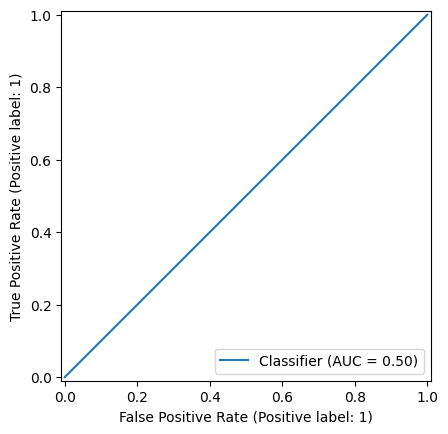

In [148]:
RocCurveDisplay.from_predictions(y_valid, y_pred_logreg)

In [149]:
print(f"{roc_auc_score(y_valid, y_pred_gauss)} vs {roc_auc(y_valid, y_pred_gauss)}")

0.5936306891621476 vs 0.5936306891621475


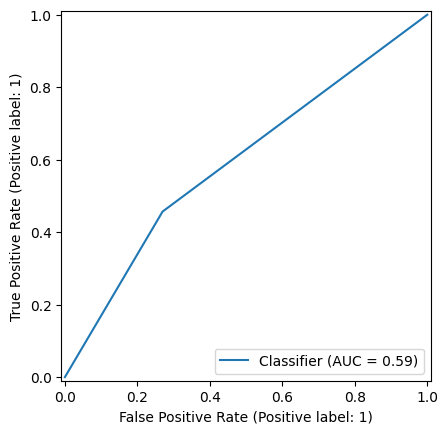

In [150]:
RocCurveDisplay.from_predictions(y_valid, y_pred_gauss)

In [151]:
print(f"{roc_auc_score(y_valid, y_pred_knn)} vs {roc_auc(y_valid, y_pred_knn)}")

0.5073517291890574 vs 0.5073517291890574


# Implement your own versions of LogisticRegression, KNN and NaiveBayes classifiers. For LogisticRegression compute gradients with respect to the loss and use stochastic gradient descent. Can you reproduce the results from step 4?

In [245]:
class MyLogisticRegression:
    def __init__(self, learning_rate=0.004, n_iter=10, batch_size=1):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.batch_size = batch_size
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
        
    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.random.randn(n_features)
        self.bias = 0
        
        
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values
        
        n_samples, n_features = X.shape
        
        self.weights = np.random.randn(n_features)
        self.bias = np.random.randn()
        
        for _ in range(self.n_iter):
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                batch_size = len(y_batch)

                z = np.dot(X_batch, self.weights) + self.bias
                y_pred = self.sigmoid(z)
                
                dw = (1/batch_size) * np.dot(X_batch.T, (y_pred - y_batch))
                db = (1/batch_size) * np.sum(y_pred - y_batch)

                dw = np.clip(dw, -1e3, 1e3)
                db = np.clip(db, -1e3, 1e3)
                
                new_weights = self.weights - self.learning_rate * dw
                new_bias = self.bias - self.learning_rate * db
        
                if np.isfinite(new_weights).all() and np.isfinite(new_bias):
                    self.weights = new_weights
                    self.bias = new_bias
                else:
                    break

    def predict_proba(self, X):     
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

In [246]:
class My_K_Nearest_Neighbors_Classifier(): 
    
    def __init__(self, K=5) :
        self.K = K
        
    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train       
        self.n_samples, self.n_features = X_train.shape
            
    def predict(self, X_test):
        self.X_test = X_test
                
        m_test, _ = X_test.shape
                
        y_predict = np.zeros(m_test)
        
        for i in range(m_test):
            x = X_test[i]
            
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            
            k_indices = np.argsort(distances)[:self.K]
            
            k_nearest_labels = self.y_train[k_indices]
            
            most_common = Counter(k_nearest_labels).most_common(1)
            y_predict[i] = most_common[0][0]
            
            
        return y_predict

In [247]:
class MyGaussianNaiveBayes():
    def __init__(self):
        pass

    def fit(self, X, y):
        classes, cls_counts = np.unique(y, return_counts=True)
        n_classes = len(classes)
        self.priors = cls_counts / len(y)

        # calculate the mean and standard deviations of features by classes
        self.X_cls_mean = np.array([np.mean(X[y == c], axis=0) for c in range(n_classes)])
        self.X_stds = np.array([np.std(X[y == c], axis=0) for c in range(n_classes)])

    def pdf(self, x, mean, std):
        if np.any(std < 1e-5):
            std = np.maximum(std, 1e-5)

        return (1 / (np.sqrt(2 * np.pi) * std)) * np.exp(-0.5 * ((x - mean) / std) ** 2)

    def predict(self, X):
        pdfs = np.array([self.pdf(x, self.X_cls_mean, self.X_stds) for x in X])
        posteriors = self.priors * np.prod(pdfs, axis=2)

        return np.argmax(posteriors, axis=1)
        

In [249]:
my_logreg = MyLogisticRegression()
my_logreg.fit(X_train1, y_train)

In [ ]:
y_pred_my_logreg = my_logreg.predict(X_valid1)
print(f"sklearn: {accuracy_score(y_valid, y_pred_logreg)} vs my model: {accuracy_score(y_valid, y_pred_my_logreg)}")

sklearn: 0.8991660348749052 vs my model: 0.8662534005262453


In [250]:
my_knn = My_K_Nearest_Neighbors_Classifier()
my_knn.fit(X_train1, y_train)

In [ ]:
y_pred_my_knn = my_knn.predict(X_valid1)
print(f"sklearn: {accuracy_score(y_valid, y_pred_knn)} vs my model: {accuracy_score(y_valid, y_pred_my_knn)}")

sklearn: 0.8929670427685859 vs my model: 0.8929670427685859


In [251]:
my_gauss = MyGaussianNaiveBayes()
my_gauss.fit(X_train1, y_train)

In [ ]:
y_pred_my_gauss = my_gauss.predict(X_valid1)
print(f"sklearn: {accuracy_score(y_valid, y_pred_gauss)} vs my model: {accuracy_score(y_valid, y_pred_my_gauss)}")

sklearn: 0.7028051554207733 vs my model: 0.8991660348749052


# Try to create non-linear features, for example:

# fractions: feature1/feature2
# groupby features: df[‘categorical_feature’].map(df.groupby(‘categorical_feature’)[‘continious_feature’].mean())

# Add new features to your pipeline, repeat step 4. Did you manage to increase your Gini score (you should!)?

In [175]:
X_train2 = X_train_new
X_test2 = X_test_new
X_valid2 = X_valid_new 

In [176]:
X_train2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22423 entries, 0 to 22422
Data columns (total 71 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              22423 non-null  int64  
 1   VehYear                            22423 non-null  int64  
 2   VehicleAge                         22423 non-null  int64  
 3   WheelTypeID                        22423 non-null  float64
 4   VehOdo                             22423 non-null  int64  
 5   MMRAcquisitionAuctionAveragePrice  22423 non-null  float64
 6   MMRAcquisitionAuctionCleanPrice    22423 non-null  float64
 7   MMRAcquisitionRetailAveragePrice   22423 non-null  float64
 8   MMRAcquisitonRetailCleanPrice      22423 non-null  float64
 9   MMRCurrentAuctionAveragePrice      22423 non-null  float64
 10  MMRCurrentAuctionCleanPrice        22423 non-null  float64
 11  MMRCurrentRetailAveragePrice       22423 non-null  flo

In [177]:
X_train2['feature1'] = X_train_new['VehYear'] / X_train_new['WarrantyCost']
X_valid2['feature1'] = X_valid_new['VehYear'] / X_valid_new['WarrantyCost']
X_test2['feature1'] = X_test_new['VehYear'] / X_test_new['WarrantyCost']

In [178]:
X_train2['feature2'] = X_train_new['MMRAcquisitionAuctionAveragePrice'] * X_train_new['MMRAcquisitionAuctionCleanPrice']
X_valid2['feature2'] = X_valid_new['MMRAcquisitionAuctionAveragePrice'] * X_valid_new['MMRAcquisitionAuctionCleanPrice']
X_test2['feature2'] = X_test_new['MMRAcquisitionAuctionAveragePrice'] * X_test_new['MMRAcquisitionAuctionCleanPrice']

In [179]:
mean_encoding = X_train_new.groupby(columns_for_count_encoder[0])[numerical_columns[0]].mean()
X_train2['feature3'] = X_train_new[columns_for_count_encoder[0]].map(mean_encoding)
mean_encoding = X_valid_new.groupby(columns_for_count_encoder[0])[numerical_columns[0]].mean()
X_valid2['feature3'] = X_valid_new[columns_for_count_encoder[0]].map(mean_encoding)
mean_encoding = X_test_new.groupby(columns_for_count_encoder[0])[numerical_columns[0]].mean()
X_test2['feature3'] = X_test_new[columns_for_count_encoder[0]].map(mean_encoding)

In [180]:
X_train2_scaled = Scaler.fit_transform(X_train2)
X_valid2_scaled = Scaler.fit_transform(X_valid2)
X_test2_scaled = Scaler.fit_transform(X_test2)

In [181]:
logreg.fit(X_train2_scaled, y_train)
print(f"then: {2 * roc_auc_score(y_valid, y_pred_logreg) - 1} vs now: {2 * roc_auc_score(y_valid, logreg.predict(X_valid2_scaled)) - 1}")

then: 0.00039268392188707146 vs now: 0.0008845643520565272


# Better result

In [182]:
gauss.fit(X_train2_scaled, y_train)
print(f"then: {2 * roc_auc_score(y_valid, y_pred_gauss) - 1} vs now: {2 * roc_auc_score(y_valid, gauss.predict(X_valid2_scaled)) - 1}")

then: 0.18726137832429512 vs now: 0.19495805777711794


# Better result

In [183]:
knn.fit(X_train2_scaled, y_train)
print(f"then: {2 * roc_auc_score(y_valid, y_pred_knn) - 1} vs now: {2 * roc_auc_score(y_valid, knn.predict(X_valid2_scaled)) - 1}")

then: 0.014703458378114709 vs now: 0.01818801542095483


# Better result

# Determine the best features for the problem using the coefficients of the logistic model. Try to eliminate useless features by hand and by L1 regularization. Which approach is better in terms of Gini score?

In [186]:
coef_df = pd.DataFrame({
    'feature': X_train2.columns,
    'coefficient': logreg.coef_[0],
    'abs_coefficient': np.abs(logreg.coef_[0])
}).sort_values('abs_coefficient', ascending=False)
coef_df

,feature,coefficient,abs_coefficient
70,feature2,0.457908,0.457908
15,VehBCost,-0.342516,0.342516
13,BYRNO,-0.185844,0.185844
2,VehicleAge,0.171188,0.171188
1,VehYear,-0.171188,0.171188
...,...,...,...
38,Color_ORANGE,0.002011,0.002011
52,Size_COMPACT,0.001390,0.001390
6,MMRAcquisitionAuctionCleanPrice,-0.000371,0.000371
29,Color_BEIGE,-0.000176,0.000176


In [188]:
logreg_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=21)
logreg_l1.fit(X_train2_scaled, y_train)
coef_df_l1 = pd.DataFrame({
    'feature': X_train2.columns,
    'coefficient': logreg_l1.coef_[0],
    'abs_coefficient': np.abs(logreg_l1.coef_[0])
}).sort_values('abs_coefficient', ascending=False)
coef_df_l1

,feature,coefficient,abs_coefficient
70,feature2,0.458250,0.458250
15,VehBCost,-0.345843,0.345843
5,MMRAcquisitionAuctionAveragePrice,-0.297965,0.297965
2,VehicleAge,0.221211,0.221211
13,BYRNO,-0.184740,0.184740
...,...,...,...
45,WheelType_Alloy,0.000000,0.000000
48,Nationality_AMERICAN,0.000000,0.000000
57,Size_MEDIUM,0.000000,0.000000
64,TopThreeAmericanName_CHRYSLER,0.000000,0.000000


In [192]:
lst_without_l1 = coef_df['feature'].where(coef_df['abs_coefficient'] > 0.001).dropna()
lst_without_l1

70                         feature2
15                         VehBCost
13                            BYRNO
2                        VehicleAge
1                           VehYear
                  ...              
8     MMRAcquisitonRetailCleanPrice
54                       Size_LARGE
42                     Color_SILVER
38                     Color_ORANGE
52                     Size_COMPACT
Name: feature, Length: 68, dtype: object

In [ ]:
lst_with_l1 = coef_df_l1['feature'].where(coef_df_l1['abs_coefficient'] > 0.001).dropna()
lst_with_l1

56

In [196]:
X_train3 = Scaler.fit_transform(X_train2[lst_without_l1])
X_valid3 = Scaler.fit_transform(X_valid2[lst_without_l1])
logreg.fit(X_train3, y_train)
2 * roc_auc_score(y_valid, logreg.predict(X_valid3)) - 1

0.0004422821760283746

In [197]:
X_train4 = Scaler.fit_transform(X_train2[lst_with_l1])
X_valid4 = Scaler.fit_transform(X_valid2[lst_with_l1])
logreg.fit(X_train4, y_train)
2 * roc_auc_score(y_valid, logreg.predict(X_valid4)) - 1

0.0008845643520565272

### For further evaluations

In [230]:
X_test4 = Scaler.fit_transform(X_test2[lst_with_l1])

### L1 regularization is way better 

# Select your best model (algorithm + feature set) and tweak its hyperparameters to increase the Gini score on the validation dataset. Which hyperparameters have the most impact?

### The best algorithm is GaussianNB, but, come on, it has so little parameters. So let`s take the best algorithm in terms of accuracy. So, going to optimize logreg

In [220]:
study = optuna.create_study(study_name="GridSearch on LogisticRegression", direction="maximize")

[I 2025-09-13 12:55:43,933] A new study created in memory with name: GridSearch on LogisticRegression


In [221]:
def objective(trial):
    C = trial.suggest_float('C', 1e-3, 10.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    solver = 'saga'
    
    if penalty == 'elasticnet':
        l1_ratio = trial.suggest_float('l1_ratio', 0.1, 0.9)
    else:
        l1_ratio = None
    
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    
    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        l1_ratio=l1_ratio,
        class_weight=class_weight,
        random_state=21,
        max_iter=1000,
        n_jobs=-1
    )
    
    model.fit(X_train4, y_train)        
    gini_score = 2 * roc_auc_score(y_valid, model.predict(X_valid4)) - 1
    
    return gini_score

In [222]:
study.optimize(objective, n_trials=20)

[I 2025-09-13 12:56:56,327] Trial 0 finished with value: 0.239597605262039 and parameters: {'C': 4.413623934749348, 'penalty': 'l2', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.239597605262039.
[I 2025-09-13 12:58:04,657] Trial 1 finished with value: 0.24700042438205427 and parameters: {'C': 0.04048321773544847, 'penalty': 'l1', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.24700042438205427.
[I 2025-09-13 12:59:17,371] Trial 2 finished with value: 0.24137083607739718 and parameters: {'C': 0.6843339361398966, 'penalty': 'elasticnet', 'l1_ratio': 0.11414358030800464, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.24700042438205427.
[I 2025-09-13 13:00:28,008] Trial 3 finished with value: 0.2411888515058105 and parameters: {'C': 0.26673646383716443, 'penalty': 'l1', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.24700042438205427.
[I 2025-09-13 13:00:33,225] Trial 4 finished with value: 0.0008845643520565272 and parameters: {'C': 0.3663

In [225]:
study.best_params

{'C': 0.0011700675558632004,
 'penalty': 'elasticnet',
 'l1_ratio': 0.12787294142666558,
 'class_weight': 'balanced'}

In [229]:
optuna_model = LogisticRegression(**study.best_params, solver='saga', max_iter=1000, random_state=21)
optuna_model.fit(X_train4, y_train)

,penalty,'elasticnet'
,dual,False
,tol,0.0001
,C,0.0011700675558632004
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,21
,solver,'saga'
,max_iter,1000
,multi_class,'deprecated'


In [231]:
coef_df = pd.DataFrame({
    'feature': lst_with_l1,
    'coefficient': optuna_model.coef_[0],
    'abs_coefficient': np.abs(optuna_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)
coef_df

,feature,coefficient,abs_coefficient
15,VehBCost,-0.194668,0.194668
2,VehicleAge,0.170527,0.170527
1,VehYear,-0.170527,0.170527
13,BYRNO,-0.144214,0.144214
4,VehOdo,0.140083,0.140083
21,Model,-0.095787,0.095787
65,TopThreeAmericanName_FORD,0.083647,0.083647
66,TopThreeAmericanName_GM,-0.056637,0.056637
27,Auction_MANHEIM,0.047077,0.047077
69,feature3,0.043026,0.043026


# Check the Gini scores on all three datasets for your best model: training Gini, valid Gini, test Gini. Do you see a drop in performance when comparing the valid quality to the test quality? Is your model overfitted or not? Explain.

In [233]:
print(f"Train: {2 * roc_auc_score(y_train, optuna_model.predict(X_train4)) - 1}")
print(f"Valid: {2 * roc_auc_score(y_valid, optuna_model.predict(X_valid4)) - 1}")
print(f"Test: {2 * roc_auc_score(y_test, optuna_model.predict(X_test4)) - 1}")

Train: 0.26811460197675707
Valid: 0.2545192213745353
Test: 0.25908695465914455


### Actually, I'm using ElasticNet regularization for LogReg, so, theoretically, overfitting must be avoided. For example, Let's check this out without regularization with the same params.

In [235]:
optuna_model_without_regularization = LogisticRegression(C=0.0011700675558632004, class_weight='balanced', solver='saga', max_iter=1000, random_state=21)
optuna_model_without_regularization.fit(X_train4, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.0011700675558632004
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,21
,solver,'saga'
,max_iter,1000
,multi_class,'deprecated'


In [236]:
print(f"Train: {2 * roc_auc_score(y_train, optuna_model_without_regularization.predict(X_train4)) - 1}")
print(f"Valid: {2 * roc_auc_score(y_valid, optuna_model_without_regularization.predict(X_valid4)) - 1}")
print(f"Test: {2 * roc_auc_score(y_test, optuna_model_without_regularization.predict(X_test4)) - 1}")

Train: 0.28295352765663195
Valid: 0.24455743067618463
Test: 0.24760967415116086


### Well, we can see a drop in training dataset in comparison to others. That's overfitting: out model took into account some features more important then they were supposed to be, so predicting on valid and test got some problems

# Implement calculation of Recall, Precision, F1 score and AUC PR metrics.
# Compare your algorithms on the test dataset using AUC PR metric.

In [238]:
def Recall_score(y_true, y_pred):
    TP = 0
    TN = 0
    FP = 0
    FN = 0
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1:
            TP += 1
        elif y_true[i] == 1 and y_pred[i] == 0:
            FN += 1
        elif y_true[i] == 0 and y_pred[i] == 1:
            FP += 1
        else:
            TN += 1

    TPR = TP / (TP + FN) if (TP + FN) != 0 else 0.5
    FPR = FP / (FP + TN) if (FP + TN) != 0 else 0.5    
    return TP / (TP + FN)

In [239]:
def Precision_score(y_true, y_pred):
    TP = 0
    TN = 0
    FP = 0
    FN = 0
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1:
            TP += 1
        elif y_true[i] == 1 and y_pred[i] == 0:
            FN += 1
        elif y_true[i] == 0 and y_pred[i] == 1:
            FP += 1
        else:
            TN += 1

    TPR = TP / (TP + FN) if (TP + FN) != 0 else 0.5
    FPR = FP / (FP + TN) if (FP + TN) != 0 else 0.5    
    return TP / (TP + FP)

In [284]:
def Accuracy_score(y_true, y_pred):
    TP = 0
    TN = 0
    FP = 0
    FN = 0
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1:
            TP += 1
        elif y_true[i] == 1 and y_pred[i] == 0:
            FN += 1
        elif y_true[i] == 0 and y_pred[i] == 1:
            FP += 1
        else:
            TN += 1

    TPR = TP / (TP + FN) if (TP + FN) != 0 else 0.5
    FPR = FP / (FP + TN) if (FP + TN) != 0 else 0.5    
    return (TP + TN) / len(y_true)

In [240]:
def F1_score(y_true, y_pred):
    Precision = Precision_score(y_true, y_pred)
    Recall = Recall_score(y_true, y_pred)
    return 2 * (Precision * Recall) / (Precision + Recall)

In [308]:
def auc_rp_score(y_true, y_pred):
    Precision = Precision_score(y_true, y_pred)
    Recall = Recall_score(y_true, y_pred)
    return (Precision * Recall) + ((1 - Recall) * Precision) / 2

In [ ]:
my_logreg.fit(X_train4, y_train)
y_pred_my_logreg = my_logreg.predict(X_test4)

In [309]:
auc_rp_score(y_test, y_pred_my_logreg)

0.11121418264275407

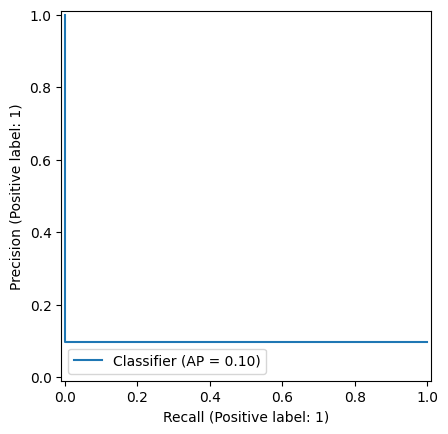

In [290]:
PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_my_logreg)

In [291]:
my_gauss.fit(X_train4, y_train)
y_pred_my_gauss = my_gauss.predict(X_test4)

In [310]:
auc_rp_score(y_test, y_pred_my_gauss)

0.11896069697254688

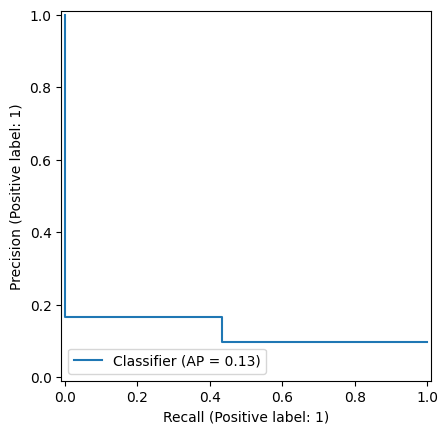

In [294]:
PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_my_gauss)

In [ ]:
my_knn.fit(X_train4, y_train)
y_pred_my_knn = my_knn.predict(X_test4)

In [ ]:
auc_rp_score(y_test, y_pred_my_knn)

In [ ]:
PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_my_knn)

# Which hard label metric do you prefer for the task of detecting "lemon" cars?

### Maybe some voting where we are asking people and make decision on their answers, of course, after making decision on a boundary (for example, 70%)